<a href="https://colab.research.google.com/github/tanviupadhyay1517/Hypothesis-Testing-/blob/main/Indep_t_test_Exam_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study
A school administrator wants to determine if students in Class A performed significantly worse on an exam than students in Class B. This analysis will help assess the teaching effectiveness of the two class instructors. [Data: exam_scores.xlsx]

# Import necessary packages

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Mounting Google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Read data

In [3]:
# Reading the data

df = pd.read_excel('/content/drive/MyDrive/Classroom/FTN Batch 10/T test Two sample/exam_scores.xlsx')

# Exploratory Analysis

In [4]:
df.columns

Index(['Class', 'Exam_Score'], dtype='object')

In [5]:
df.head()                                   # Viewing first few observations of the data

,Class,Exam_Score
0,A,49.967142
1,A,43.617357
2,A,51.476885
3,A,60.230299
4,A,42.658466


In [6]:
df.describe()                               # Descriptive statistics

,Exam_Score
count,100.000000
mean,46.461535
std,9.743353
min,23.802549
25%,40.360043
50%,46.815627
75%,53.229297
max,65.646437


<Axes: title={'center': 'Exam_Score'}, xlabel='Class'>

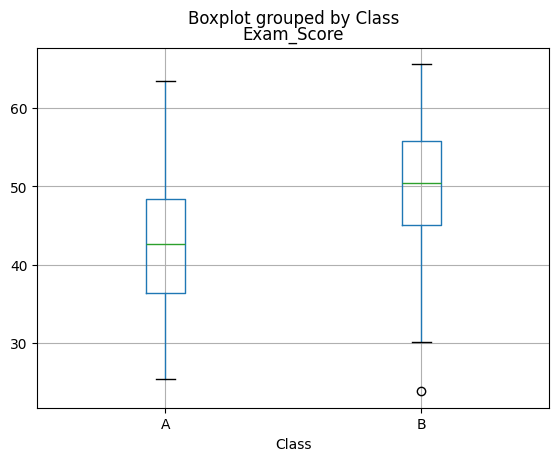

In [7]:
df.boxplot(by ='Class', column =['Exam_Score'])  # Box-plot

# Normality test using Shapiro test

In [8]:
Shapiro1 = stats.shapiro(df.Exam_Score[df.Class == 'A'])
print("Shapiro-Wilk test for Class A:", Shapiro1)

Shapiro-Wilk test for Class A: ShapiroResult(statistic=np.float64(0.9827494614161075), pvalue=np.float64(0.672207564902706))


In [9]:
Shapiro2 = stats.shapiro(df.Exam_Score[df.Class == 'B'])
print("Shapiro-Wilk test for Class B:", Shapiro2)

Shapiro-Wilk test for Class B: ShapiroResult(statistic=np.float64(0.9713165278190066), pvalue=np.float64(0.26161374906535906))


# Normality check using Q-Q plot

In [10]:
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot

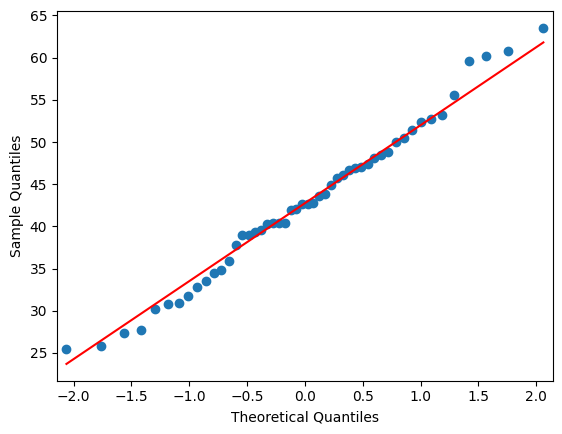

In [11]:
qqplot(df[df['Class'] == 'A']['Exam_Score'], line='s')
plt.show()

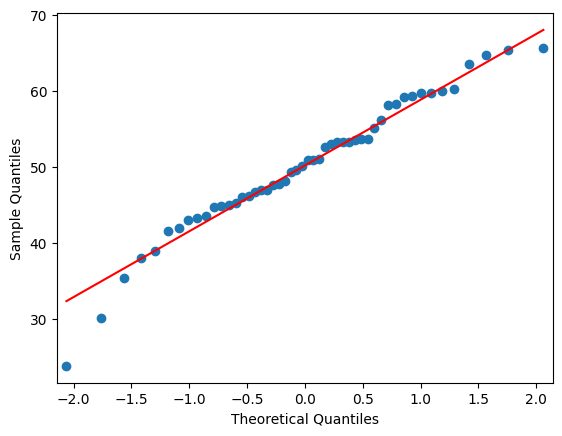

In [12]:
qqplot(df[df['Class'] == 'B']['Exam_Score'], line='s')
plt.show()


## Testing Equality of Variances

In [13]:
# Levene test using Center as Mean
stats.levene(df.Exam_Score[df.Class == 'A'],df.Exam_Score[df.Class == 'B'],center='mean')

LeveneResult(statistic=np.float64(0.2823637410039442), pvalue=np.float64(0.596358489976571))

# Independent t test

In [15]:
res = stats.ttest_ind(df.Exam_Score[df.Class == 'A'],df.Exam_Score[df.Class == 'B'],equal_var=True,
  alternative='two-sided')
res

TtestResult(statistic=np.float64(-4.108723928204809), pvalue=np.float64(8.261945608702613e-05), df=np.float64(98.0))

In [17]:
print("Average performance of Class A:",(df.Exam_Score[df.Class == 'A']).mean())
print("Average performance of Class B:",(df.Exam_Score[df.Class == 'B']).mean())

Average performance of Class A: 42.745260947438595
Average performance of Class B: 50.17780870467952
